In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from mne.filter import filter_data

### Config

In [35]:
CHANNEL_NAMES = [
    "FP1", "F3",  "F7",  "C3",
    "T3",  "P3",  "T5",  "O1",
    "FP2", "F4",  "F8",  "C4",
    "T4",  "P4",  "T6",  "O2"
]

SUBJECT = "Z"
ROOT    = f"../data/subject{SUBJECT}"
DATE    = "20260618"

files  = [f for f in os.listdir(ROOT) if f.endswith(".csv")]
STAMPS = np.unique([f.split("_")[-1][:-4] for f in files if f"{SUBJECT}_eeg_{DATE}" in f])

STAMP_ID = 4
STAMP    = STAMPS[STAMP_ID]
print(f"Available: {STAMPS}")
print(f"Loading   STAMP={STAMP}")

FS = 250.

# Stimulus-locked window (around onset)
PRE_STIM  = 0.2   # s before stimulus
POST_STIM = 1.5   # s after stimulus

# Movement-locked window (around button press)
PRE_PRESS  = 2.0  # s before press  (captures BP ramp)
POST_PRESS = 0.5  # s after press

Available: ['125821' '131405' '133154' '140110' '153514' '155418']
Loading   STAMP=153514


#### Load data

In [36]:
# Loading EEG
df_eeg     = pd.read_csv(f"{ROOT}/{SUBJECT}_eeg_{DATE}_{STAMP}.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG        = df_eeg.iloc[:, 1:-1].values
button     = df_eeg.iloc[:, -1].values.astype(bool)

N, N_CHANNELS = EEG.shape
print(f"EEG shape: {EEG.shape}  ({N / FS:.1f} s)")

EEG shape: (190853, 16)  (763.4 s)


In [37]:
# Loading markers
df_markers = pd.read_csv(f"{ROOT}/{SUBJECT}_markers_{DATE}_{STAMP}.csv")

#### Align marker timestamps to EEG clock

EEG timestamps are saved with `time_correction` applied (wall-clock reference),
but markers used raw `local_clock()` (boot-relative).  
We recover the offset using the first button-press rising edge visible in both signals.

> **Fixed in `gng_task.py`** — future sessions won't need this cell.

In [38]:
# Rising edges in EEG button channel (ch16)
BUTTON_EDGES = np.where(np.diff(button.astype(int)) > 0)[0]

# Prefer SP press as anchor; fall back to first GO hit if no SP block was run
SP_MKR_TIMES      = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values
GO_PRESS_MKR_TIMES = df_markers.loc[
    (df_markers.marker_code == 30) & (df_markers.trial_type == "go")
].lsl_timestamp.values

HAS_SP = len(SP_MKR_TIMES) > 0

if len(BUTTON_EDGES) > 0 and HAS_SP:
    EEG_FIRST_PRESS = timestamps[BUTTON_EDGES[0] + 1]
    MKR_FIRST_PRESS = SP_MKR_TIMES[0]
    anchor          = "selfpaced_press (code 41)"
elif len(BUTTON_EDGES) > 0 and len(GO_PRESS_MKR_TIMES) > 0:
    EEG_FIRST_PRESS = timestamps[BUTTON_EDGES[0] + 1]
    MKR_FIRST_PRESS = GO_PRESS_MKR_TIMES[0]
    anchor          = "go_press (code 30) — no SP block"
else:
    EEG_FIRST_PRESS = MKR_FIRST_PRESS = None
    anchor          = None

if EEG_FIRST_PRESS is not None:
    TS_OFFSET = EEG_FIRST_PRESS - MKR_FIRST_PRESS
    df_markers["lsl_timestamp"] = df_markers["lsl_timestamp"] + TS_OFFSET
    print(f"TS_OFFSET = {TS_OFFSET:.3f} s  (anchor: {anchor})")
else:
    TS_OFFSET = 0.0
    print("WARNING: could not compute TS_OFFSET — check BUTTON_EDGES and marker file")

TS_OFFSET = 1780742191.748 s  (anchor: go_press (code 30) — no SP block)


In [39]:
df_eeg.head()

,lsl_timestamp,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,1.781831e+09,-186787.437500,-161577.625000,-181642.156250,-33230.429688,-118724.500000,-88835.296875,-166276.312500,-140041.62500,-174652.593750,-31093.779297,-177398.906250,800430.7500,12967.139648,-170924.312500,-122177.039062,-161990.687500,0.0
1,1.781831e+09,-186756.062500,-161672.046875,-181707.593750,-33211.378906,-118699.562500,-88811.968750,-166290.265625,-140034.65625,-174784.546875,-31015.460938,-177428.671875,800557.6250,13024.809570,-170943.359375,-122152.367188,-161946.953125,0.0
2,1.781831e+09,-186748.015625,-161733.734375,-181745.953125,-33215.140625,-118686.406250,-88800.968750,-166312.796875,-140040.81250,-174768.734375,-30988.369141,-177401.843750,800596.8125,13042.780273,-170923.515625,-122135.742188,-161920.140625,0.0
3,1.781831e+09,-186785.828125,-161736.953125,-181753.734375,-33250.011719,-118719.406250,-88817.601562,-166343.906250,-140064.43750,-174677.531250,-31034.769531,-177393.265625,800577.7500,13018.370117,-170924.578125,-122159.609375,-161949.906250,0.0
4,1.781831e+09,-186820.437500,-161677.671875,-181723.156250,-33281.390625,-118754.273438,-88843.351562,-166344.703125,-140073.81250,-174652.859375,-31067.220703,-177413.375000,800581.7500,13010.320312,-170948.453125,-122175.968750,-161975.125000,0.0


In [40]:
df_markers.head(20)

,lsl_timestamp,marker_code,marker_label,trial_type
0,1.781831e+09,10,go_onset,go
1,1.781831e+09,30,button_press,go
2,1.781831e+09,11,hit,go
3,1.781831e+09,20,nogo_onset,nogo
4,1.781831e+09,21,correct_rejection,nogo
5,1.781831e+09,10,go_onset,go
6,1.781831e+09,30,button_press,go
7,1.781831e+09,11,hit,go
8,1.781831e+09,20,nogo_onset,nogo
9,1.781831e+09,21,correct_rejection,nogo


In [41]:
df_markers.trial_type.value_counts()

trial_type
go      300
nogo    203
Name: count, dtype: int64

### Preprocess EEG

In [42]:
EEG = filter_data(EEG.T[None], FS, 0.5, 28., verbose=False).squeeze()

In [43]:
# Apply CAR
EEG -= EEG.mean(axis=0, keepdims=True)

---
## Stimulus-locked ERPs: GO vs NOGO

Epochs locked to stimulus onset.  
Look for **N2** (~200 ms) and **P3** (~300–400 ms), largest at frontocentral electrodes.

| Marker code | Event      |
|-------------|------------|
| 10          | go_onset   |
| 20          | nogo_onset |

In [44]:
N_PRE_STIM  = int(PRE_STIM  * FS)
N_POST_STIM = int(POST_STIM * FS)
N_STIM      = N_PRE_STIM + N_POST_STIM + 1
T_STIM      = np.linspace(-PRE_STIM, POST_STIM, N_STIM)

In [45]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []
for onset in go_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        GO_ERP.append(EEG[:, i0:i1])

GO_ERP = np.stack(GO_ERP)
print(f"GO epochs: {len(GO_ERP)}")

GO epochs: 99


In [46]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []
for onset in nogo_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        NOGO_ERP.append(EEG[:, i0:i1])

NOGO_ERP = np.stack(NOGO_ERP)
print(f"NOGO epochs: {len(NOGO_ERP)}")

NOGO epochs: 100


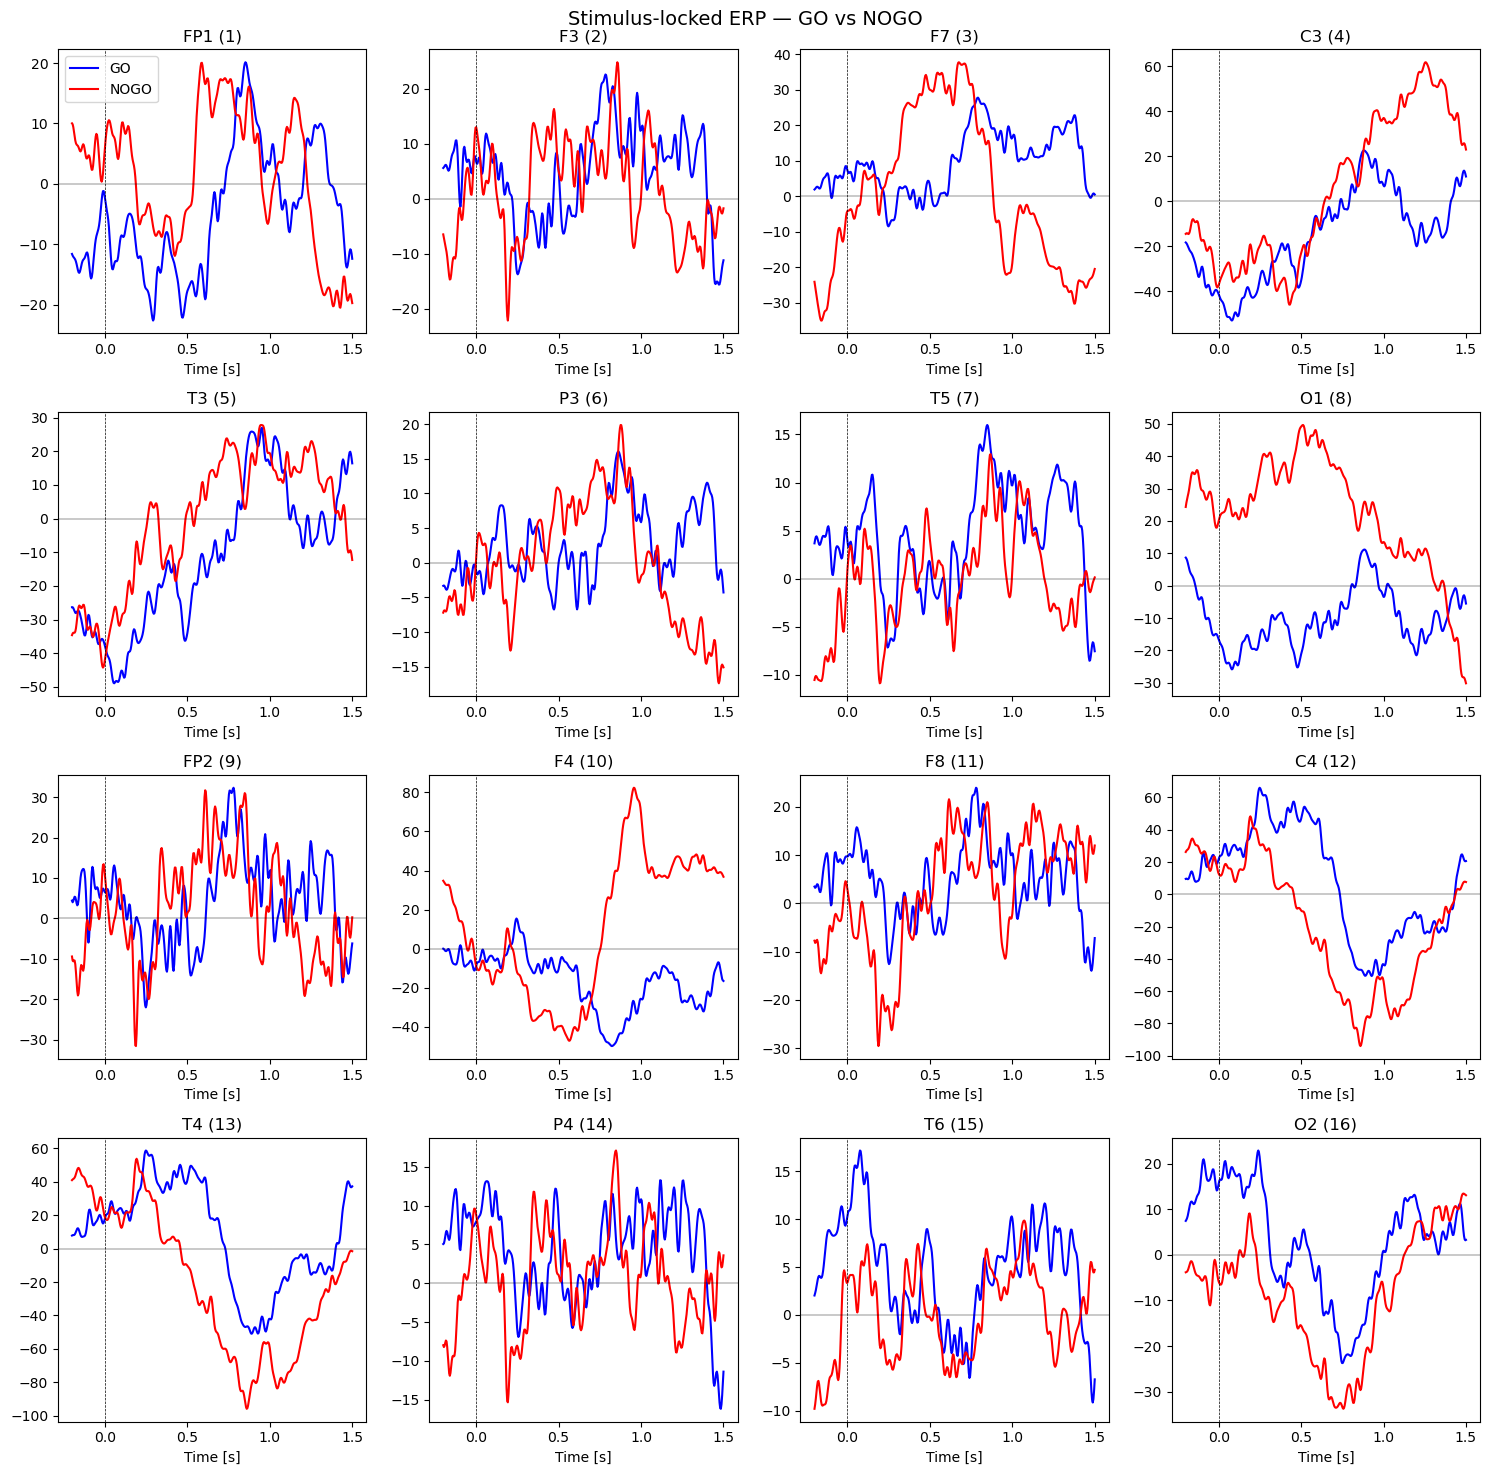

In [47]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_STIM, GO_ERP.mean(0)[pos],   "b", label="GO")
    plt.plot(T_STIM, NOGO_ERP.mean(0)[pos], "r", label="NOGO")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Stimulus-locked ERP — GO vs NOGO", fontsize=14)
plt.tight_layout()

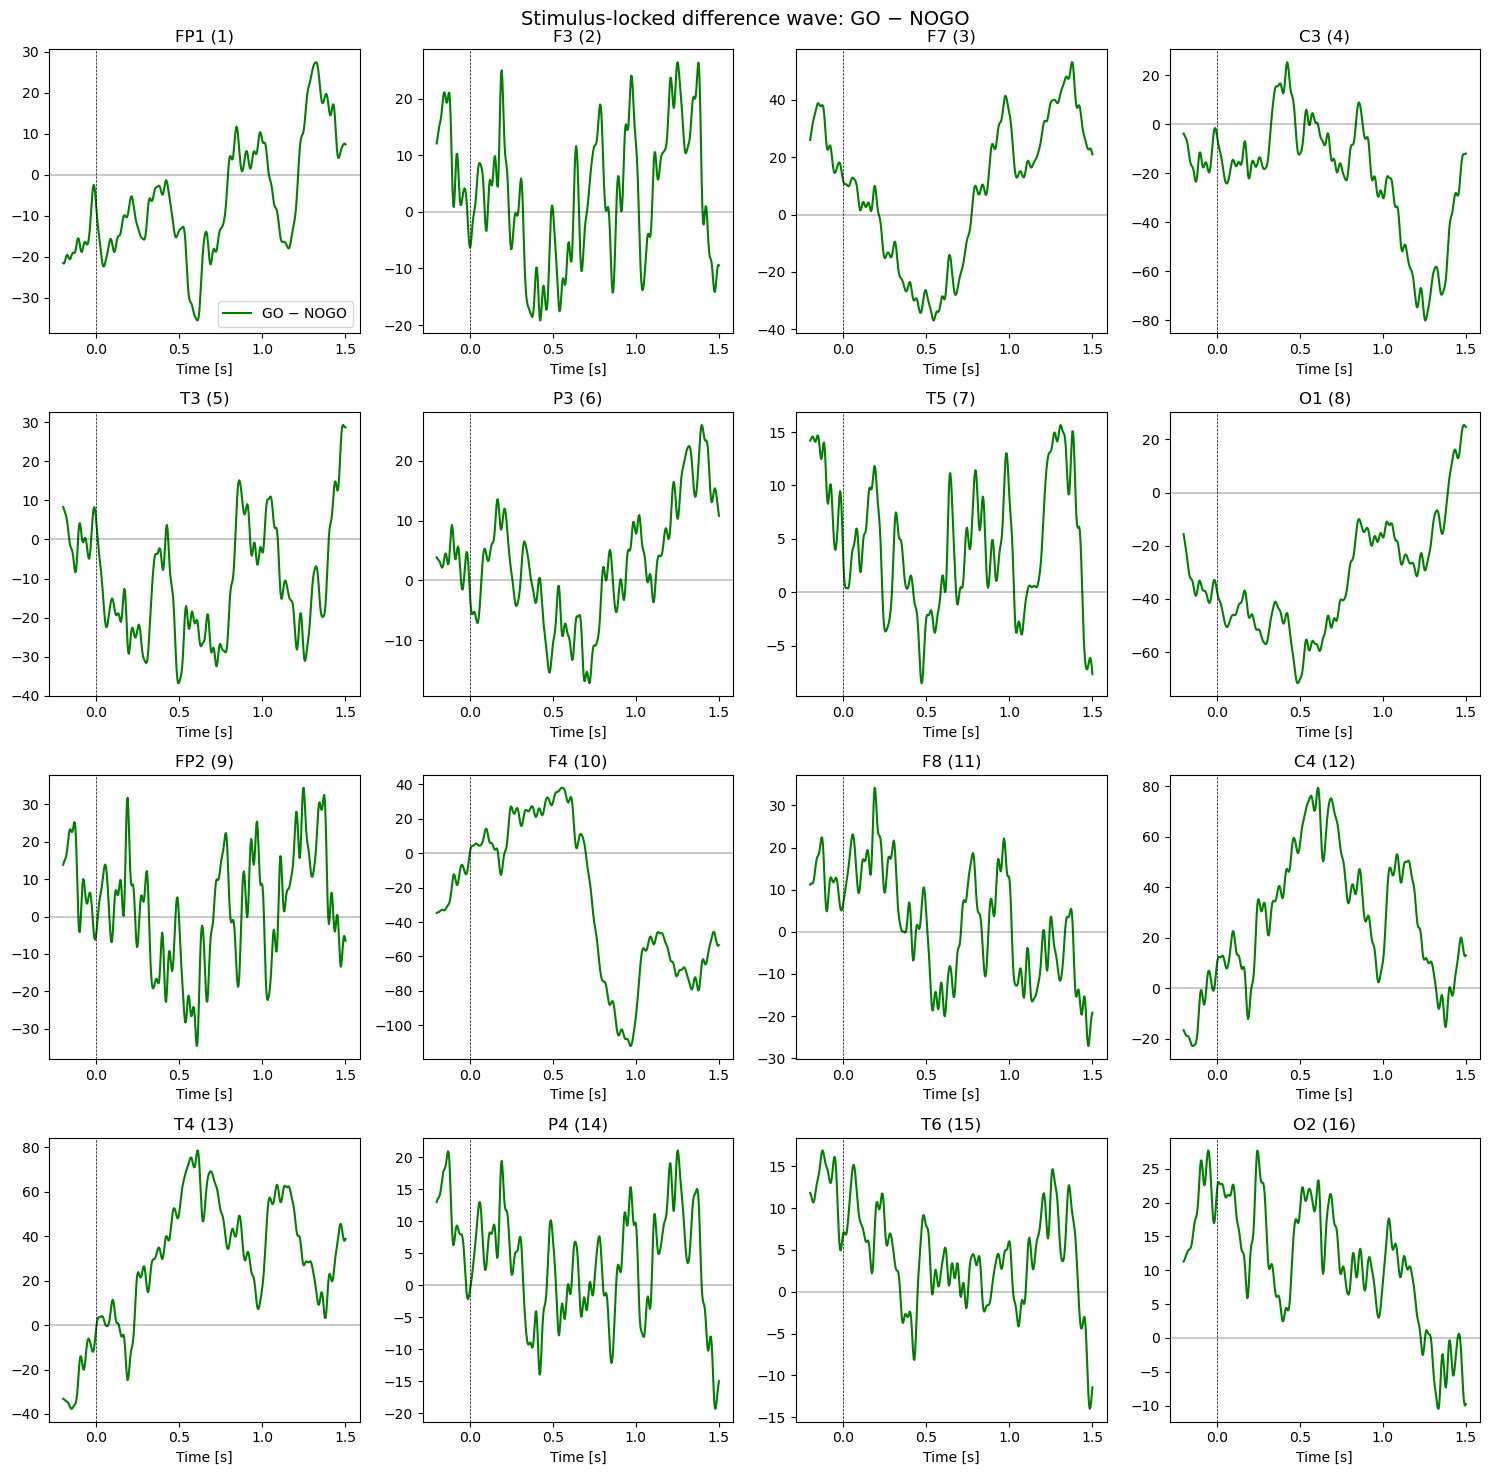

In [48]:
# GO - NOGO difference wave
GO_MINUS_NOGO = GO_ERP.mean(axis=0) - NOGO_ERP.mean(axis=0)

plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_STIM, GO_MINUS_NOGO[pos], "g", label="GO − NOGO")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Stimulus-locked difference wave: GO − NOGO", fontsize=14)
plt.tight_layout()

---
## Movement-locked ERPs: GO hit vs Self-paced

Epochs locked to **button press**.  
Look for the **Bereitschaftspotential** — slow negative ramp starting ~1–1.5 s before press, maximal at **Cz** (ch C3, index 3 in this cap).

| Marker code | Event             |
|-------------|-------------------|
| 30          | button_press (GO) |
| 41          | selfpaced_press   |

In [49]:
N_PRE_PRESS  = int(PRE_PRESS  * FS)
N_POST_PRESS = int(POST_PRESS * FS)
N_PRESS      = N_PRE_PRESS + N_POST_PRESS + 1
T_PRESS      = np.linspace(-PRE_PRESS, POST_PRESS, N_PRESS)

In [50]:
# GO hits only (button_press on go trials)
go_press_times = df_markers.loc[
    (df_markers.marker_code == 30) & (df_markers.trial_type == "go")
].lsl_timestamp.values

GO_PRESS_ERP = []
for t in go_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        GO_PRESS_ERP.append(EEG[:, i0:i1])

GO_PRESS_ERP = np.stack(GO_PRESS_ERP)
print(f"GO hit press epochs: {len(GO_PRESS_ERP)}")

GO hit press epochs: 98


In [51]:
# Self-paced presses (voluntary, no cue)
sp_press_times = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values
print(f"Self-paced press events found: {len(sp_press_times)}")

SP_ERP = []
for t in sp_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        SP_ERP.append(EEG[:, i0:i1])

SP_ERP = np.stack(SP_ERP) if SP_ERP else None
print(f"SP epochs after boundary check: {len(SP_ERP) if SP_ERP is not None else 0}")

Self-paced press events found: 0
SP epochs after boundary check: 0


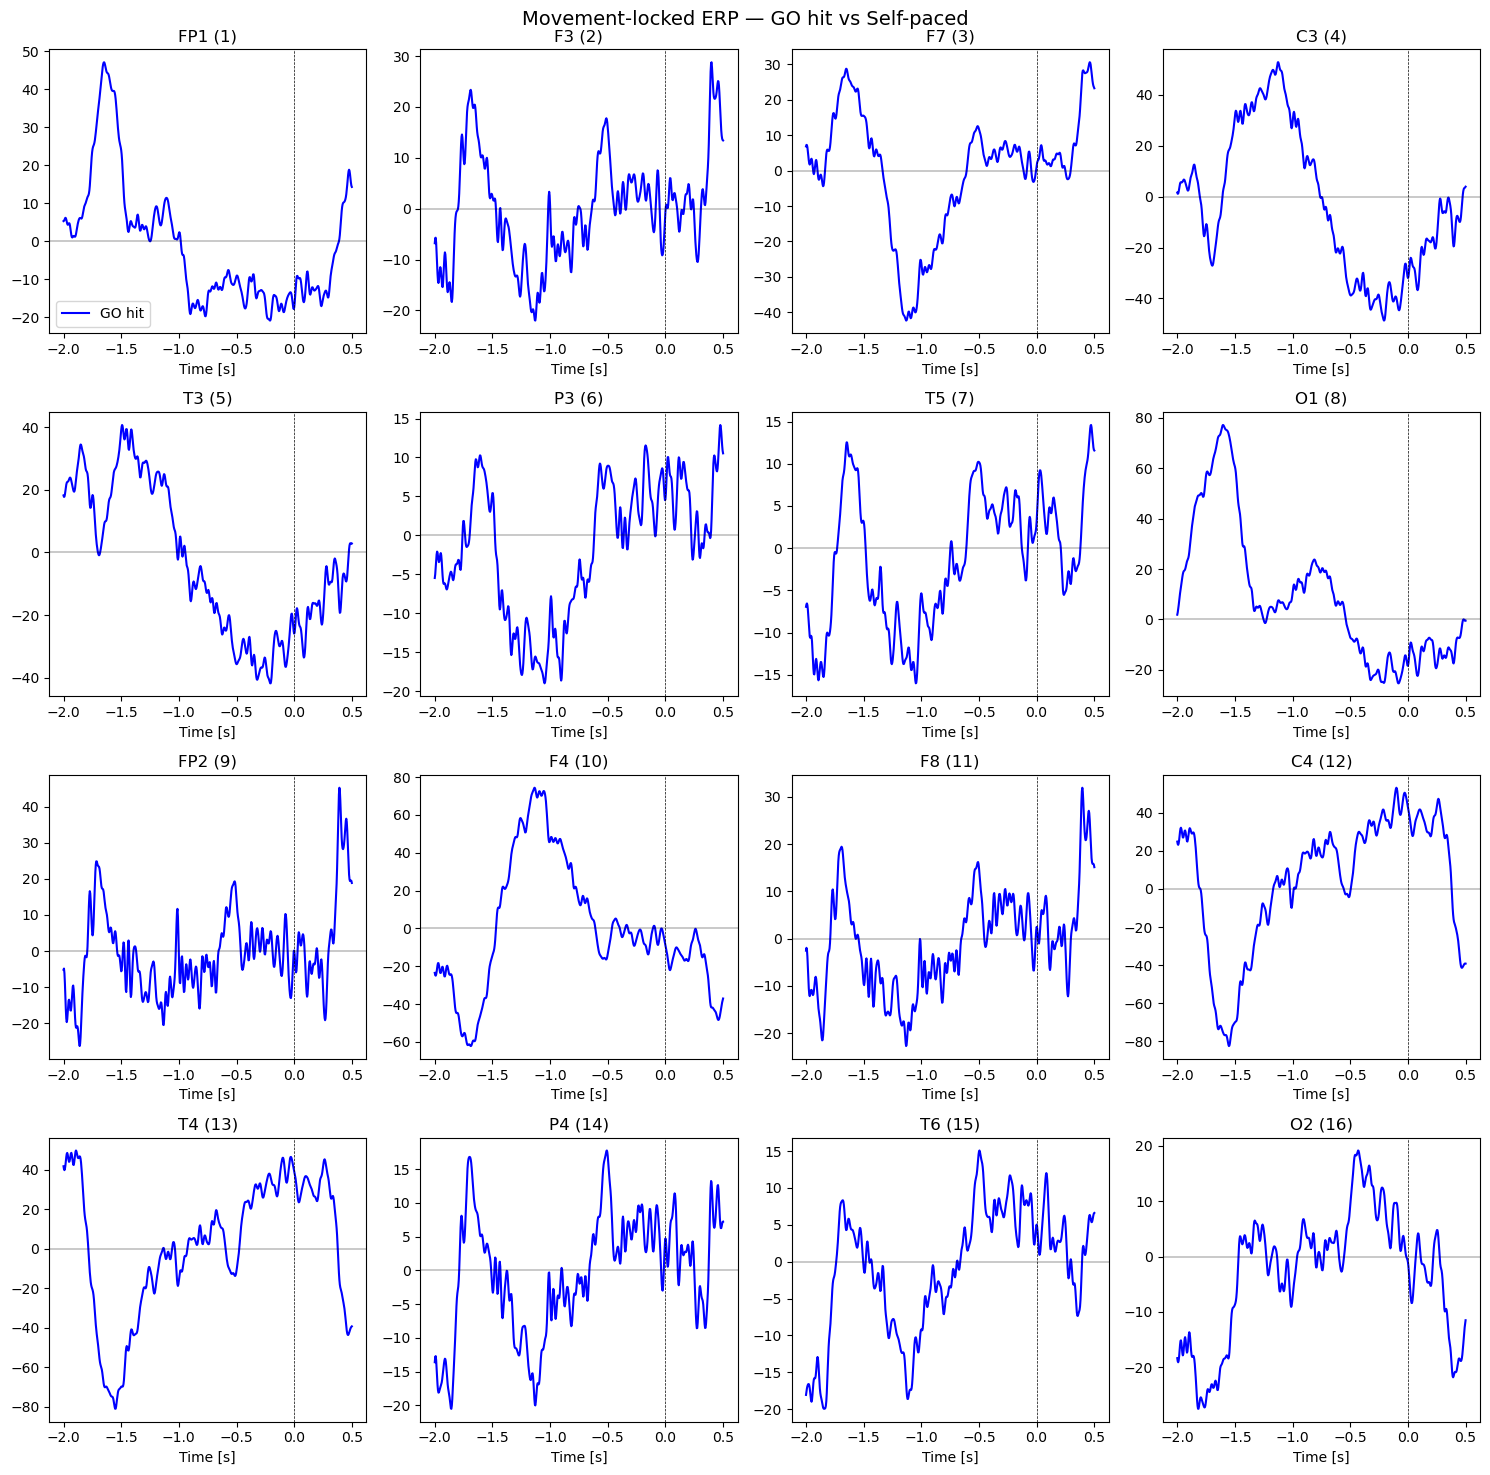

In [52]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_PRESS, GO_PRESS_ERP.mean(0)[pos], "b", label="GO hit")
    if SP_ERP is not None:
        plt.plot(T_PRESS, SP_ERP.mean(0)[pos], "g", label="Self-paced")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Movement-locked ERP — GO hit vs Self-paced", fontsize=14)
plt.tight_layout()

---
## Summary: all conditions at Cz

Cz is channel index 3 (C3 in this 16-ch cap — adjust `CZ` if needed).  
Stimulus-locked and movement-locked have different time axes — plotted side by side.

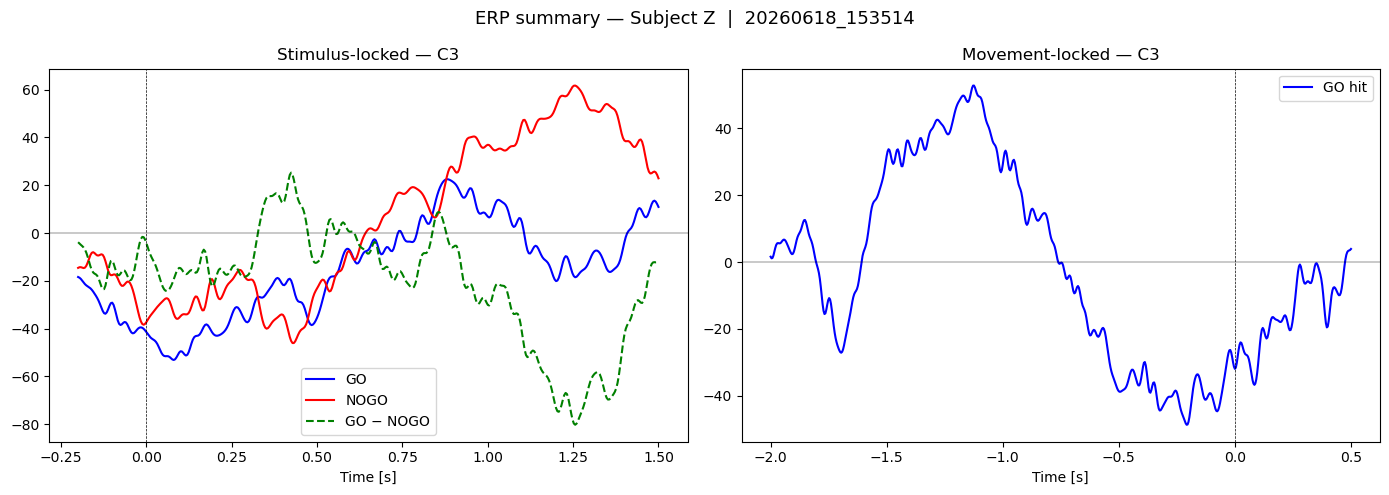

In [53]:
CZ = 3  # C3 position in this cap — adjust if your Cz is different

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_STIM, GO_ERP.mean(0)[CZ],   "b",   label="GO")
ax.plot(T_STIM, NOGO_ERP.mean(0)[CZ], "r",   label="NOGO")
ax.plot(T_STIM, GO_MINUS_NOGO[CZ],    "g--", label="GO − NOGO")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Stimulus-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

ax = axes[1]
ax.plot(T_PRESS, GO_PRESS_ERP.mean(0)[CZ], "b", label="GO hit")
if SP_ERP is not None:
    ax.plot(T_PRESS, SP_ERP.mean(0)[CZ], "g", label="Self-paced")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Movement-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

plt.suptitle(f"ERP summary — Subject {SUBJECT}  |  {DATE}_{STAMP}", fontsize=13)
plt.tight_layout()